17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: (25000, 200)
Testing samples: (25000, 200)

Model Architecture


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 240ms/step - accuracy: 0.7850 - loss: 0.4494 - val_accuracy: 0.8600 - val_loss: 0.3324
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 248ms/step - accuracy: 0.8982 - loss: 0.2631 - val_accuracy: 0.8720 - val_loss: 0.3056
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - accuracy: 0.9337 - loss: 0.1808 - val_accuracy: 0.8718 - val_loss: 0.3266
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.9524 - loss: 0.1337 - val_accuracy: 0.8584 - val_loss: 0.3551
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 233ms/step - accuracy: 0.9652 - loss: 0.1030 - val_accuracy: 0.8632 - val_loss: 0.4552


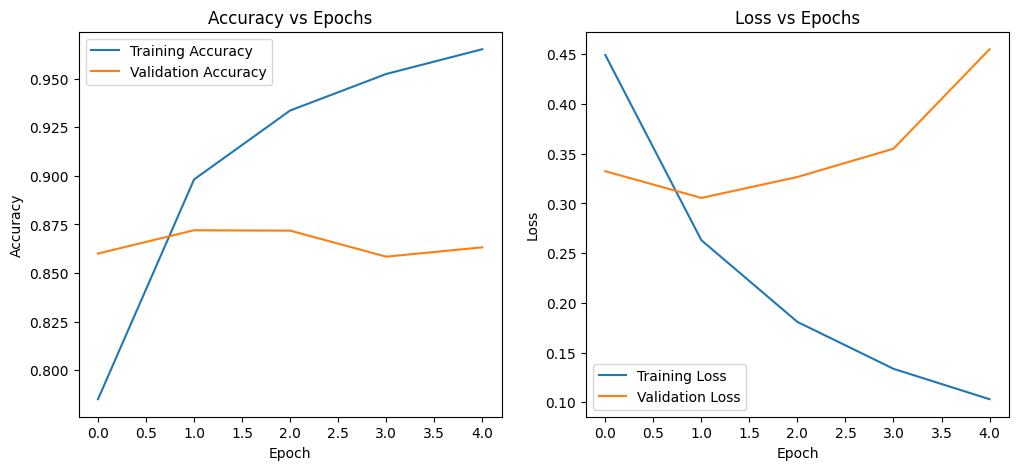

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8598 - loss: 0.4627

Model Evaluation
Test Loss: 0.4627303183078766
Test Accuracy: 0.8597599864006042
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step


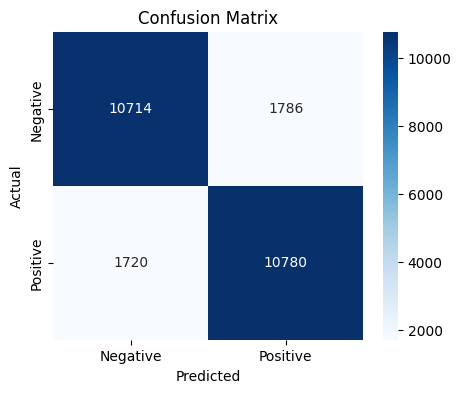


Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



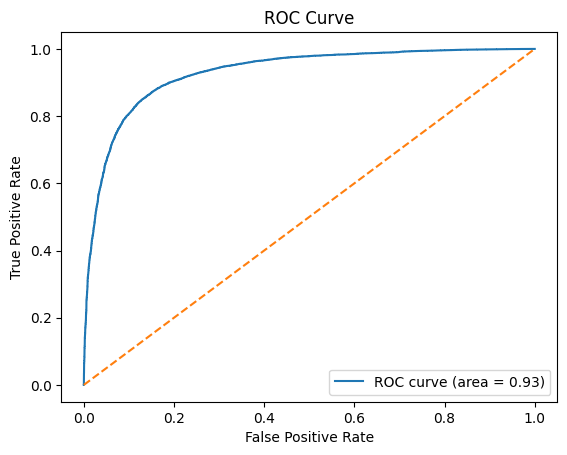


Prediction Interpretation

Review 1
Actual Sentiment : Negative
Predicted Sentiment: Negative
Prediction Confidence: 0.052
----------------------------------------
Review 2
Actual Sentiment : Positive
Predicted Sentiment: Positive
Prediction Confidence: 0.999
----------------------------------------
Review 3
Actual Sentiment : Positive
Predicted Sentiment: Negative
Prediction Confidence: 0.086
----------------------------------------
Review 4
Actual Sentiment : Negative
Predicted Sentiment: Positive
Prediction Confidence: 0.838
----------------------------------------
Review 5
Actual Sentiment : Positive
Predicted Sentiment: Positive
Prediction Confidence: 1.0
----------------------------------------


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
vocab_size = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)
model = Sequential([Embedding(vocab_size, 128, input_length=max_len),LSTM(64),Dense(1, activation='sigmoid')])
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
print("\nModel Architecture")
model.summary()

history = model.fit(
X_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nModel Evaluation")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

predictions = model.predict(X_test)
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
xticklabels=["Negative","Positive"],
yticklabels=["Negative","Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report")
print(classification_report(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("\nPrediction Interpretation\n")
for i in range(5):
    prob = predictions[i][0]
    predicted_sentiment = "Positive" if prob > 0.5 else "Negative"
    actual_sentiment = "Positive" if y_test[i] == 1 else "Negative"
    print(f"Review {i+1}")
    print("Actual Sentiment :", actual_sentiment)
    print("Predicted Sentiment:", predicted_sentiment)
    print("Prediction Confidence:", round(prob,3))
    print("-"*40)